# Mall Customers

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

### LOAD DATASET

In [2]:
df = pd.read_csv("Mall_Customers.csv")

### BASIC EDA

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### FEATURE SELECTION

In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

### FEATURE SCALING

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### ELBOW METHOD FOR KMEANS

In [9]:
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

C:\Users\ninga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ninga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ninga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ninga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

### PLOT ELBOW GRAPH

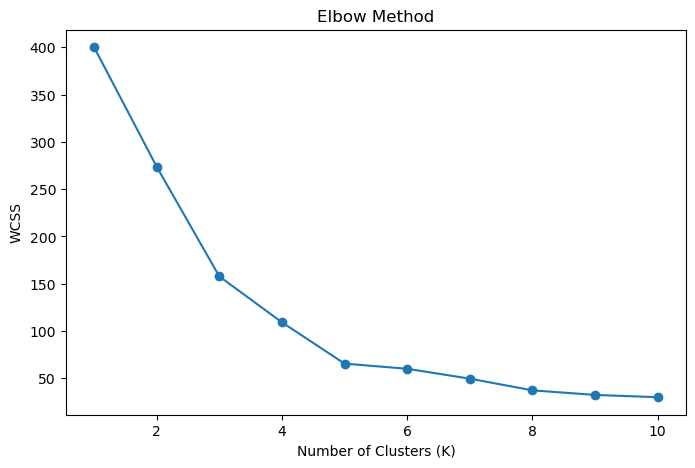

In [10]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

### KMEANS CLUSTERING

In [11]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Add labels to dataframe
df['KMeans_Cluster'] = kmeans_labels

C:\Users\ninga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### KMEANS SILHOUETTE SCORE

In [ ]:
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("KMeans Silhouette Score:", kmeans_score)

# VISUALIZE KMEANS
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=kmeans_labels,
    palette='viridis'
)

plt.title("KMeans Clustering")

plt.show()

### AGGLOMERATIVE CLUSTERING

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=5
)

agg_labels = agg.fit_predict(X_scaled)

# Add labels to dataframe
df['Agglomerative_Cluster'] = agg_labels

### AGGLOMERATIVE SCORE

In [ ]:
agg_score = silhouette_score(
    X_scaled,
    agg_labels
)

print("Agglomerative Silhouette Score:", agg_score)

### VISUALIZE AGGLOMERATIVE

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=agg_labels,
    palette='rainbow'
)

plt.title("Agglomerative Clustering")

plt.show()

### DBSCAN CLUSTERING

In [ ]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

# Add labels
df['DBSCAN_Cluster'] = db_labels

### DBSCAN SCORE

In [ ]:
# DBSCAN may create noise (-1)

if len(set(db_labels)) > 1:

    db_score = silhouette_score(
        X_scaled,
        db_labels
    )

    print("DBSCAN Silhouette Score:", db_score)

else:

    print("DBSCAN created only one cluster")

### VISUALIZE DBSCAN

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=db_labels,
    palette='deep'
)

plt.title("DBSCAN Clustering")

plt.show()

### CLUSTER ANALYSIS

In [ ]:
print("\nKMeans Cluster Analysis")
print(
    df.groupby('KMeans_Cluster')[
        ['Annual Income (k$)',
         'Spending Score (1-100)']
    ].mean()
)



# FINAL DATAFRAME

df.head()